# Credit Risk Dataset: Exploratory Data Analysis

**Authors:** Illian Hashatel, Reda Allab, Issa Ali Adoum  
**Course:** Data Science Software, M2 IRFA, Université Paris 1

---

This notebook covers the exploratory analysis conducted before modeling. The goal is to understand the structure of the data, identify quality issues, and spot the variables most associated with default risk.

**Outline**
1. Loading and first look
2. Missing values
3. Target variable: class imbalance
4. Numerical features: distributions and outliers
5. Categorical features: distributions and default rates
6. Bivariate analysis: numerical features vs default
7. Correlation analysis

## 1. Loading and first look

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.style import (
    set_style, BLUE, RED, AQUA, TARGET_COLORS, TARGET_LABELS,
    MODEL_COLORS, DIVERGING_BLUE_RED, AXIS_LINE,
)

set_style()
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('../data/credit_risk_dataset.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [3]:
df.describe().round(2)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.00,32581.00,31686.00,32581.00,29465.00,32581.00,32581.00,32581.00
mean,27.73,66074.85,4.79,9589.37,11.01,0.22,0.17,5.80
std,6.35,61983.12,4.14,6322.09,3.24,0.41,0.11,4.06
min,20.00,4000.00,0.00,500.00,5.42,0.00,0.00,2.00
25%,23.00,38500.00,2.00,5000.00,7.90,0.00,0.09,3.00
50%,26.00,55000.00,4.00,8000.00,10.99,0.00,0.15,4.00
75%,30.00,79200.00,7.00,12200.00,13.47,0.00,0.23,8.00
max,144.00,6000000.00,123.00,35000.00,23.22,1.00,0.83,30.00


## 2. Missing values

Two variables contain missing values. Before imputing them, it is worth checking whether missingness itself carries predictive signal: if borrowers with missing data default at a different rate than the rest, the absence of information is informative and should be explicitly modeled.

                   count   pct
person_emp_length    895  2.75
loan_int_rate       3116  9.56


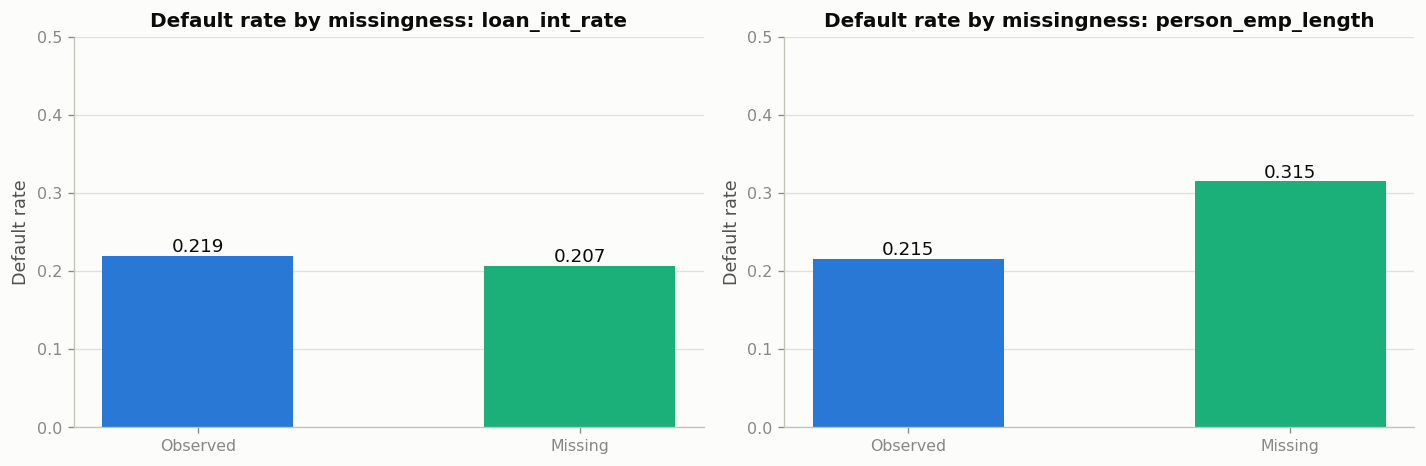

In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0].to_frame('count')
missing['pct'] = (missing['count'] / len(df) * 100).round(2)
print(missing)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ['loan_int_rate', 'person_emp_length']):
    default_rate = df.groupby(df[col].isna())['loan_status'].mean()
    default_rate.index = ['Observed', 'Missing']
    ax.bar(default_rate.index, default_rate.values,
           color=[BLUE, AQUA], width=0.5)
    ax.set_title(f'Default rate by missingness: {col}')
    ax.set_ylabel('Default rate')
    ax.set_ylim(0, 0.5)
    for i, v in enumerate(default_rate.values):
        ax.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=11, color='#0b0b0b')

plt.tight_layout()
plt.show()

If the two bars differ noticeably for a variable, its missingness is informative and a binary indicator should be added before imputation. This is the approach adopted in the modeling notebook.

## 3. Target variable: class imbalance

With ~22% defaults, the dataset is moderately imbalanced. This rules out accuracy as a reliable evaluation metric and calls for strategies such as balanced class weights during training.

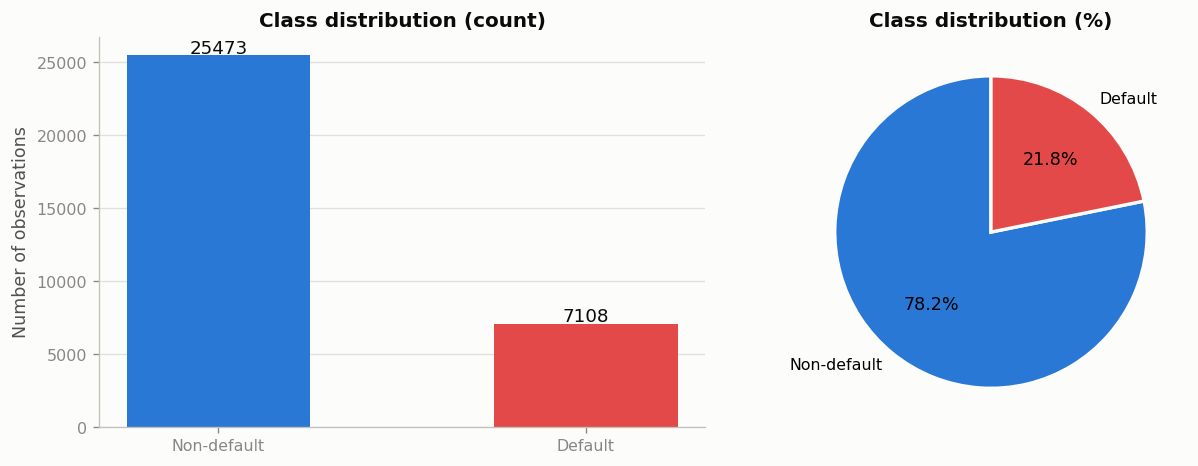

Non-default: 25,473 (78.2%)
Default:     7,108 (21.8%)


In [5]:
counts = df['loan_status'].value_counts()
labels = [TARGET_LABELS[0], TARGET_LABELS[1]]
colors = [TARGET_COLORS[0], TARGET_COLORS[1]]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(labels, counts.values, color=colors, width=0.5)
axes[0].set_title('Class distribution (count)')
axes[0].set_ylabel('Number of observations')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontsize=11, color='#0b0b0b')

axes[1].pie(
    counts.values, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': '#fcfcfb', 'linewidth': 2}
)
axes[1].set_title('Class distribution (%)')

plt.tight_layout()
plt.show()

print(f'Non-default: {counts[0]:,} ({counts[0]/len(df)*100:.1f}%)')
print(f'Default:     {counts[1]:,} ({counts[1]/len(df)*100:.1f}%)')

## 4. Numerical features: distributions and outliers

We inspect the distribution of each numerical variable and flag potential outliers. Two variables stand out: `person_age` (max = 144) and `person_emp_length` (max = 123 years), which are clearly data entry errors. These observations will be removed during preprocessing.

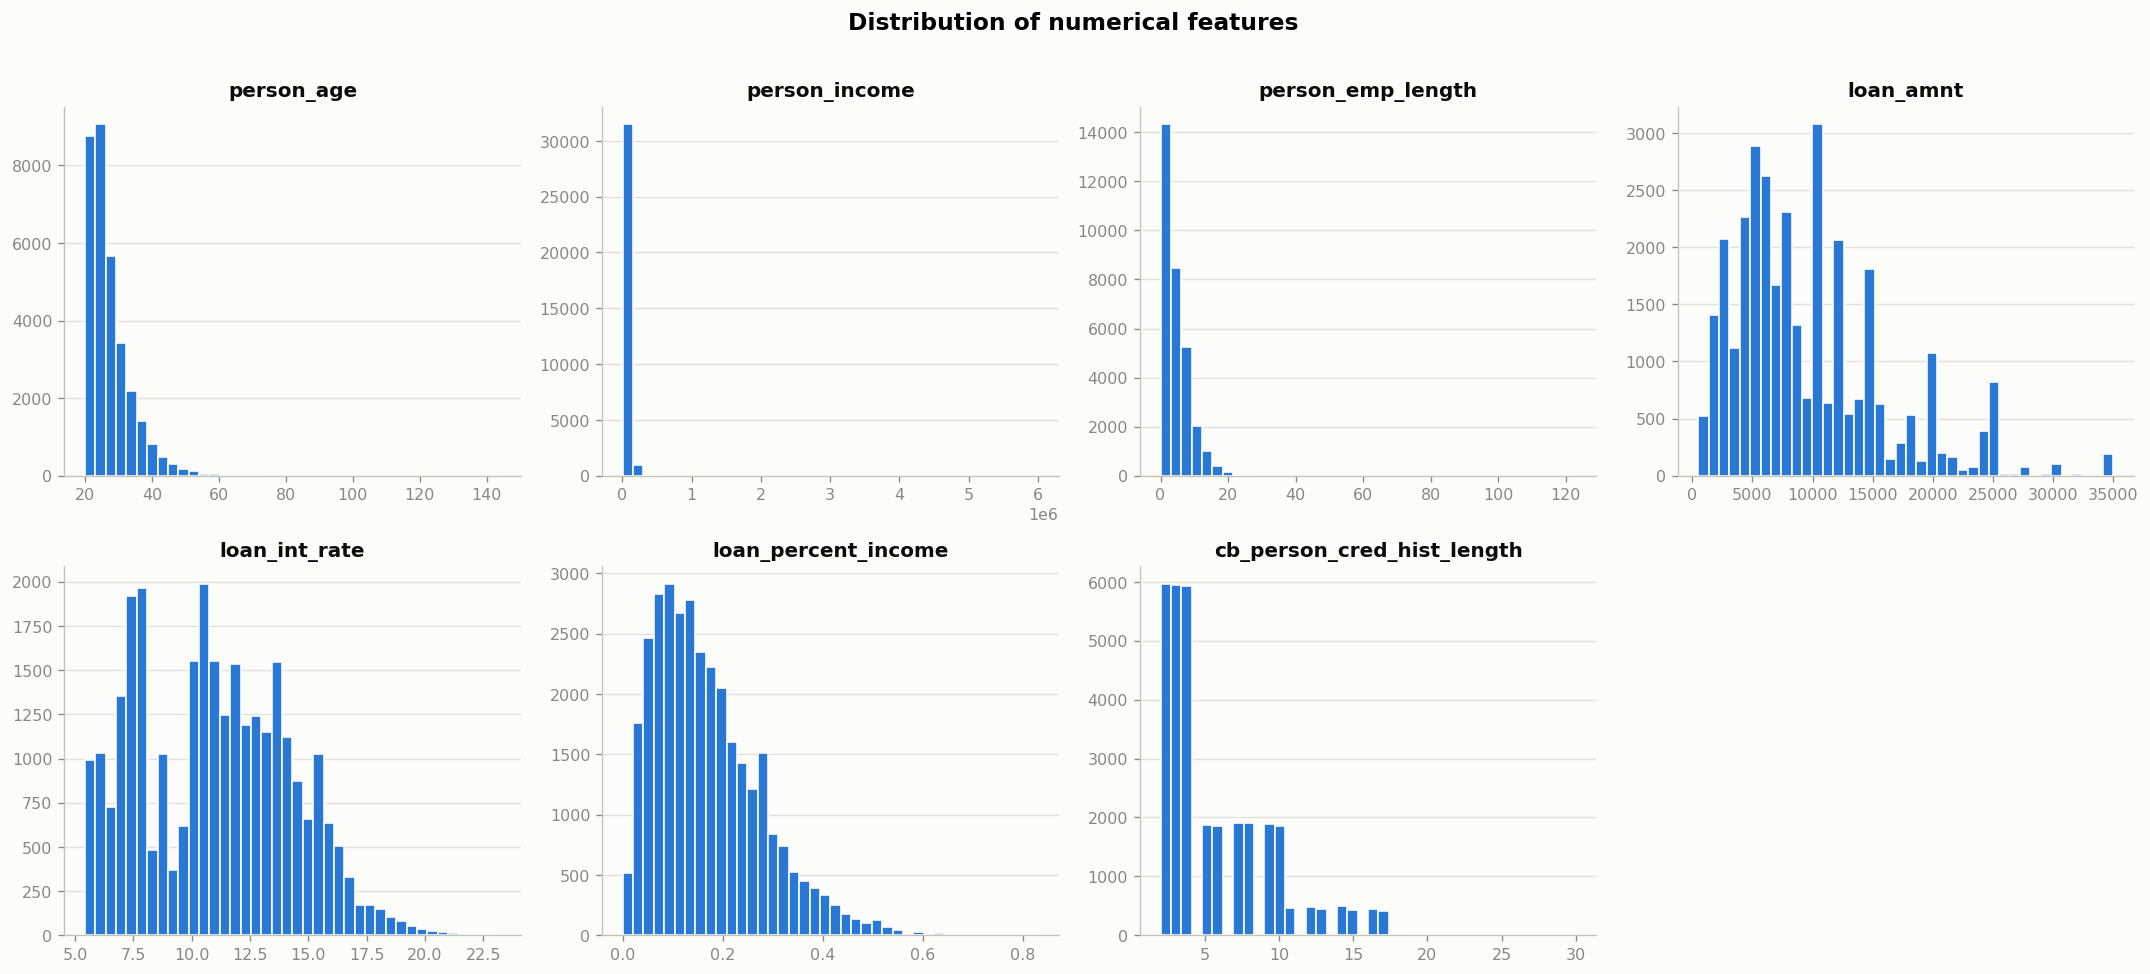

In [6]:
num_cols = ['person_age', 'person_income', 'person_emp_length',
            'loan_amnt', 'loan_int_rate', 'loan_percent_income',
            'cb_person_cred_hist_length']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    ax.hist(df[col].dropna(), bins=40, color=BLUE, edgecolor='#fcfcfb')
    ax.set_title(col)
    ax.set_xlabel('')

axes[-1].set_visible(False)
plt.suptitle('Distribution of numerical features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

person_age > 100: 5 observations
person_emp_length > 60: 2 observations
person_income > 500k: 53 observations


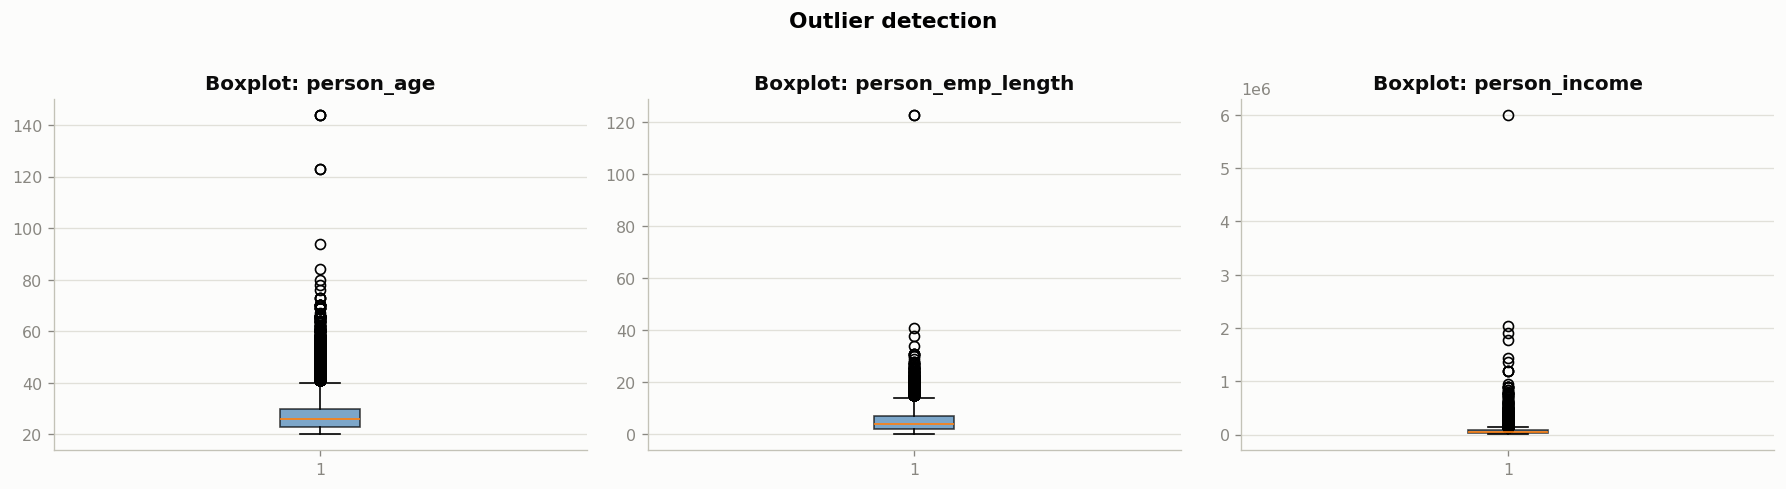

In [7]:
# Outlier check
print('person_age > 100:', (df['person_age'] > 100).sum(), 'observations')
print('person_emp_length > 60:', (df['person_emp_length'] > 60).sum(), 'observations')
print('person_income > 500k:', (df['person_income'] > 500_000).sum(), 'observations')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['person_age', 'person_emp_length', 'person_income']):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.7))
    ax.set_title(f'Boxplot: {col}')

plt.suptitle('Outlier detection', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Categorical features: distributions and default rates

For each categorical variable we show both its marginal distribution and the default rate per category. The default rate is the key quantity: a variable is useful for prediction if it separates high-risk and low-risk categories.

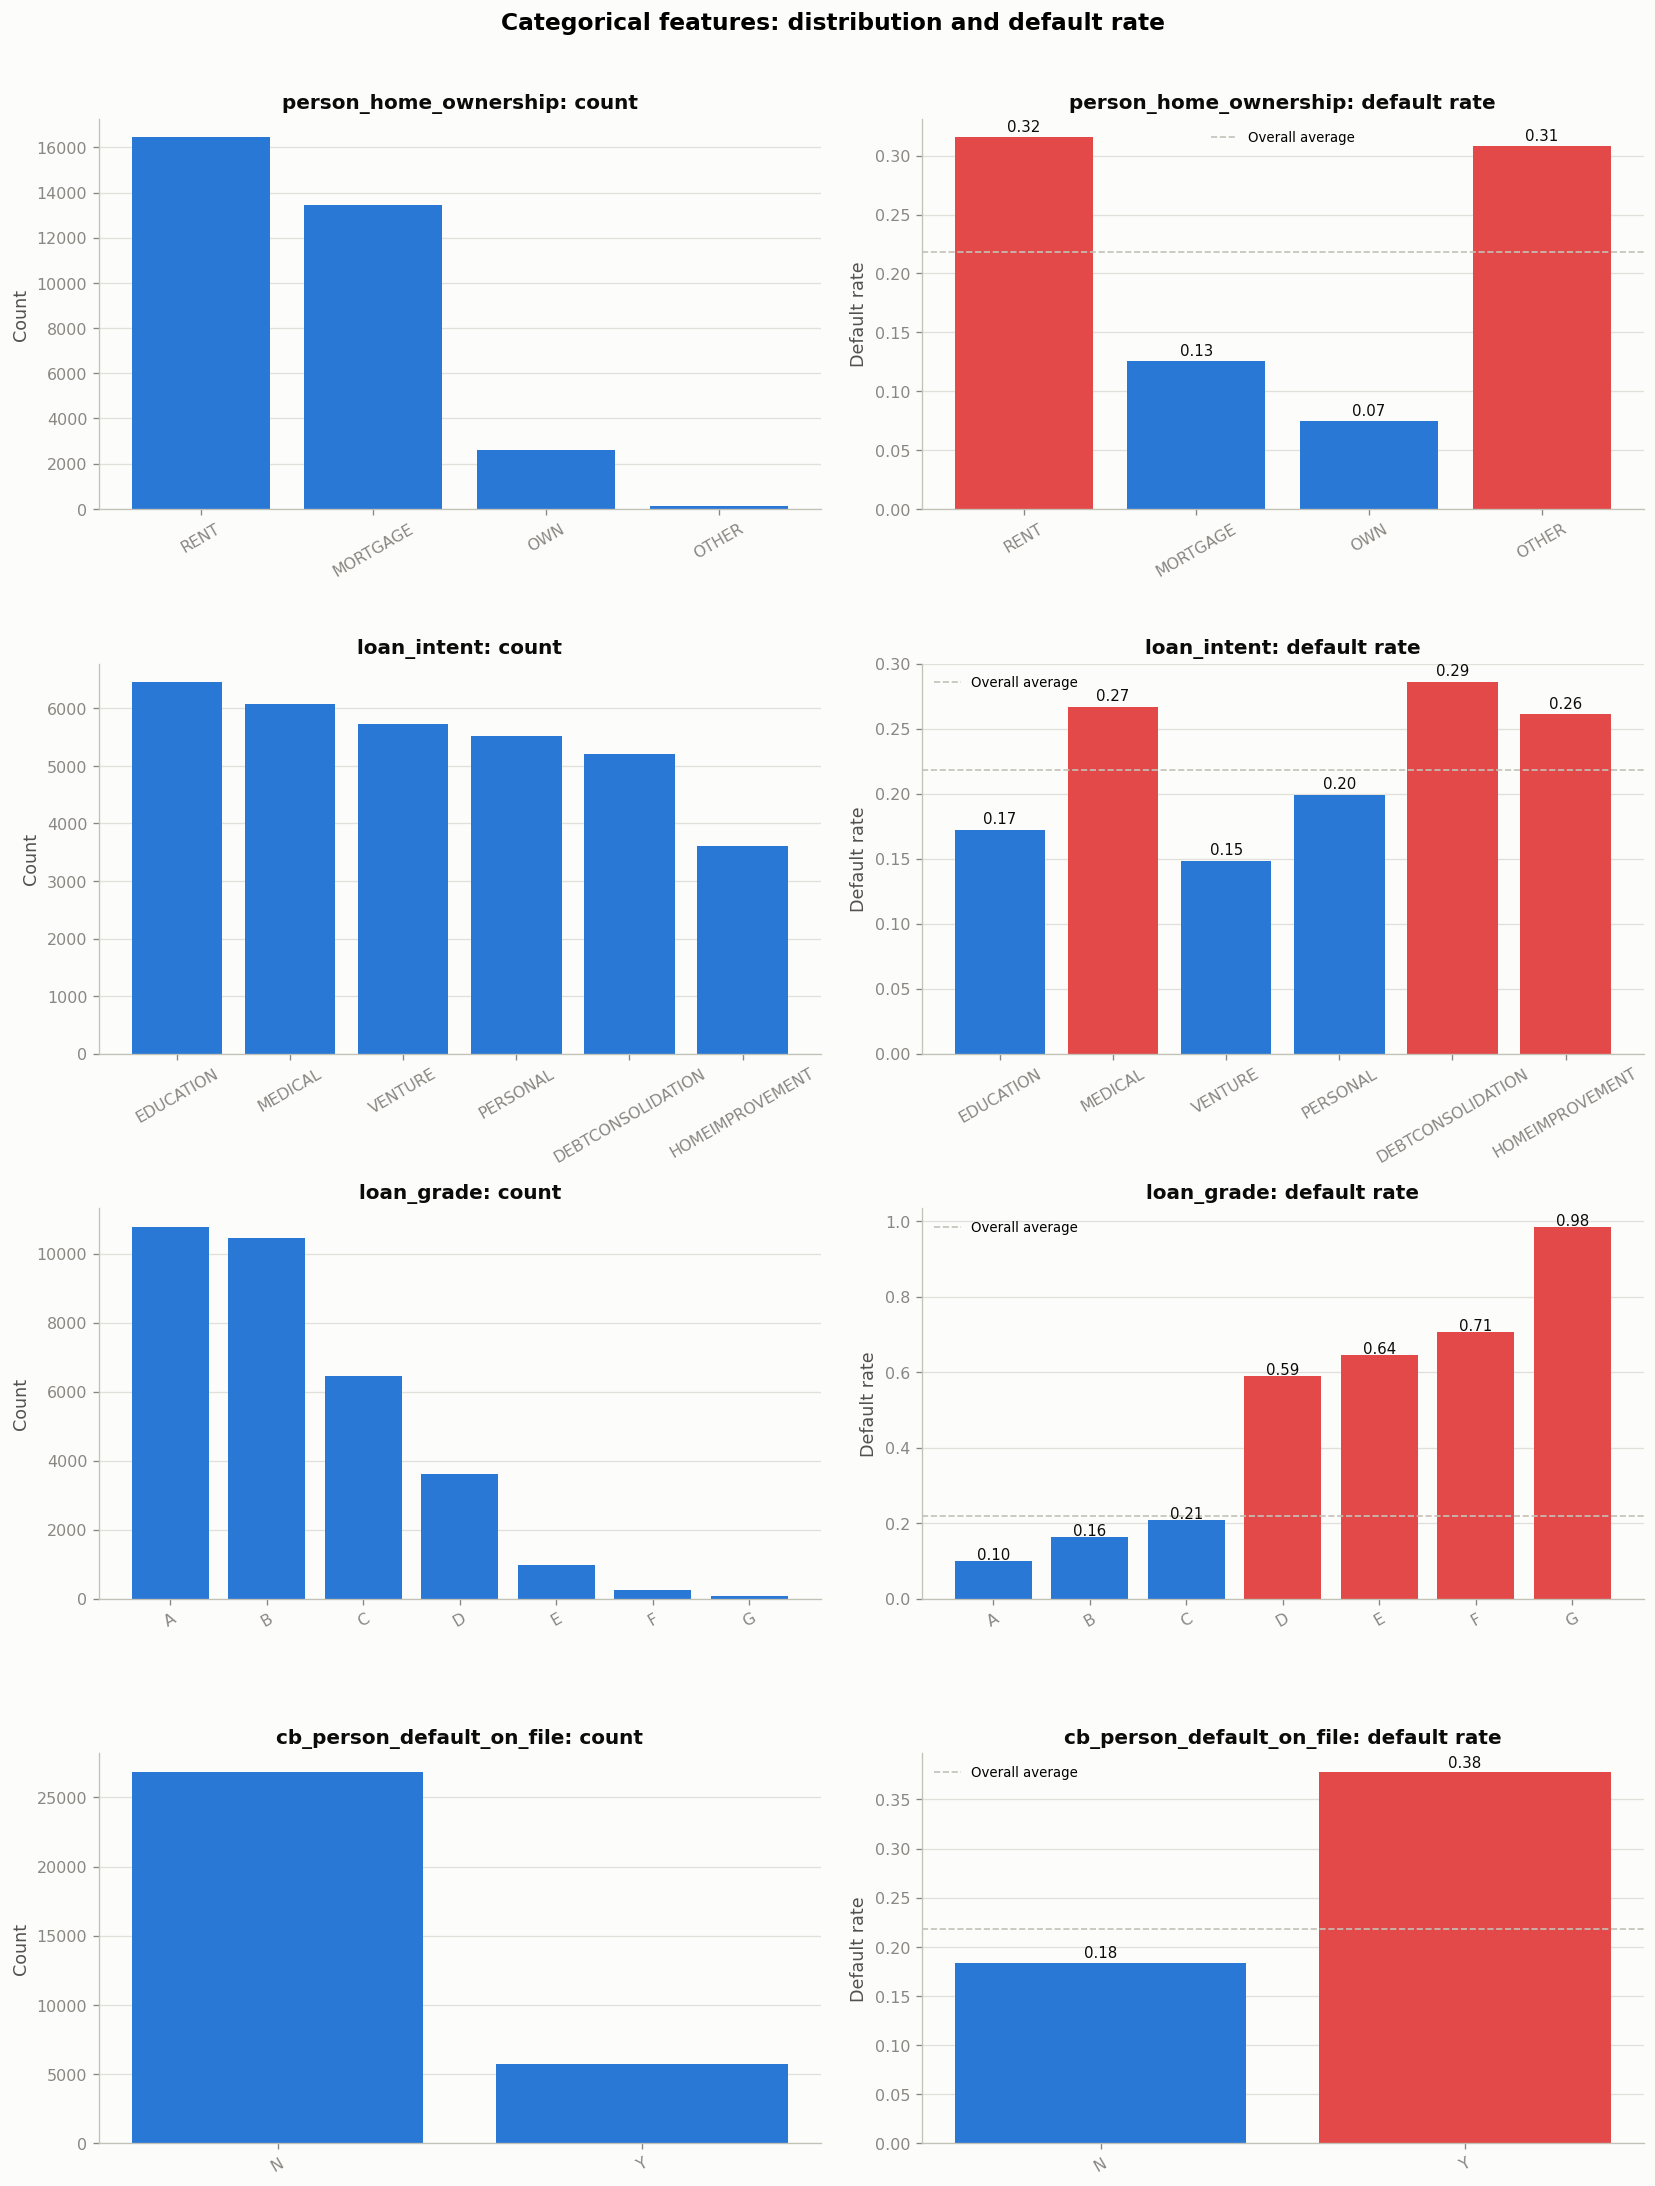

In [8]:
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

fig, axes = plt.subplots(4, 2, figsize=(14, 18))

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    default_rate = df.groupby(col)['loan_status'].mean().reindex(counts.index)

    # Left: count distribution
    axes[i, 0].bar(counts.index, counts.values, color=BLUE)
    axes[i, 0].set_title(f'{col}: count')
    axes[i, 0].set_ylabel('Count')
    axes[i, 0].tick_params(axis='x', rotation=30)

    # Right: default rate per category (highlight above-average in red)
    bar_colors = [RED if v > df['loan_status'].mean() else BLUE
                  for v in default_rate.values]
    axes[i, 1].bar(default_rate.index, default_rate.values, color=bar_colors)
    axes[i, 1].axhline(df['loan_status'].mean(), color=AXIS_LINE,
                       linestyle='--', linewidth=1, label='Overall average')
    axes[i, 1].set_title(f'{col}: default rate')
    axes[i, 1].set_ylabel('Default rate')
    axes[i, 1].tick_params(axis='x', rotation=30)
    axes[i, 1].legend(fontsize=8)
    for j, (cat, val) in enumerate(default_rate.items()):
        axes[i, 1].text(j, val + 0.005, f'{val:.2f}', ha='center', fontsize=9, color='#0b0b0b')

plt.suptitle('Categorical features: distribution and default rate', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

A few observations stand out:

- **`loan_grade`** is by far the strongest predictor: default rates range from 10% (grade A) to 98% (grade G). The signal is almost monotonic.
- **`person_home_ownership`**: renters default at 31.6%, almost three times more than homeowners (7.5%). This variable acts as a proxy for financial stability.
- **`loan_intent`**: debt consolidation and medical loans have the highest default rates (28.6% and 26.7%). Education and venture loans are safer.
- **`cb_person_default_on_file`**: borrowers with a prior default on file default at 37.8% vs 18.4% for others, a strong historical signal.

## 6. Bivariate analysis: numerical features vs default

We compare the distribution of each numerical variable between defaulters and non-defaulters using overlapping histograms and boxplots. A clear separation between the two groups indicates a useful feature.

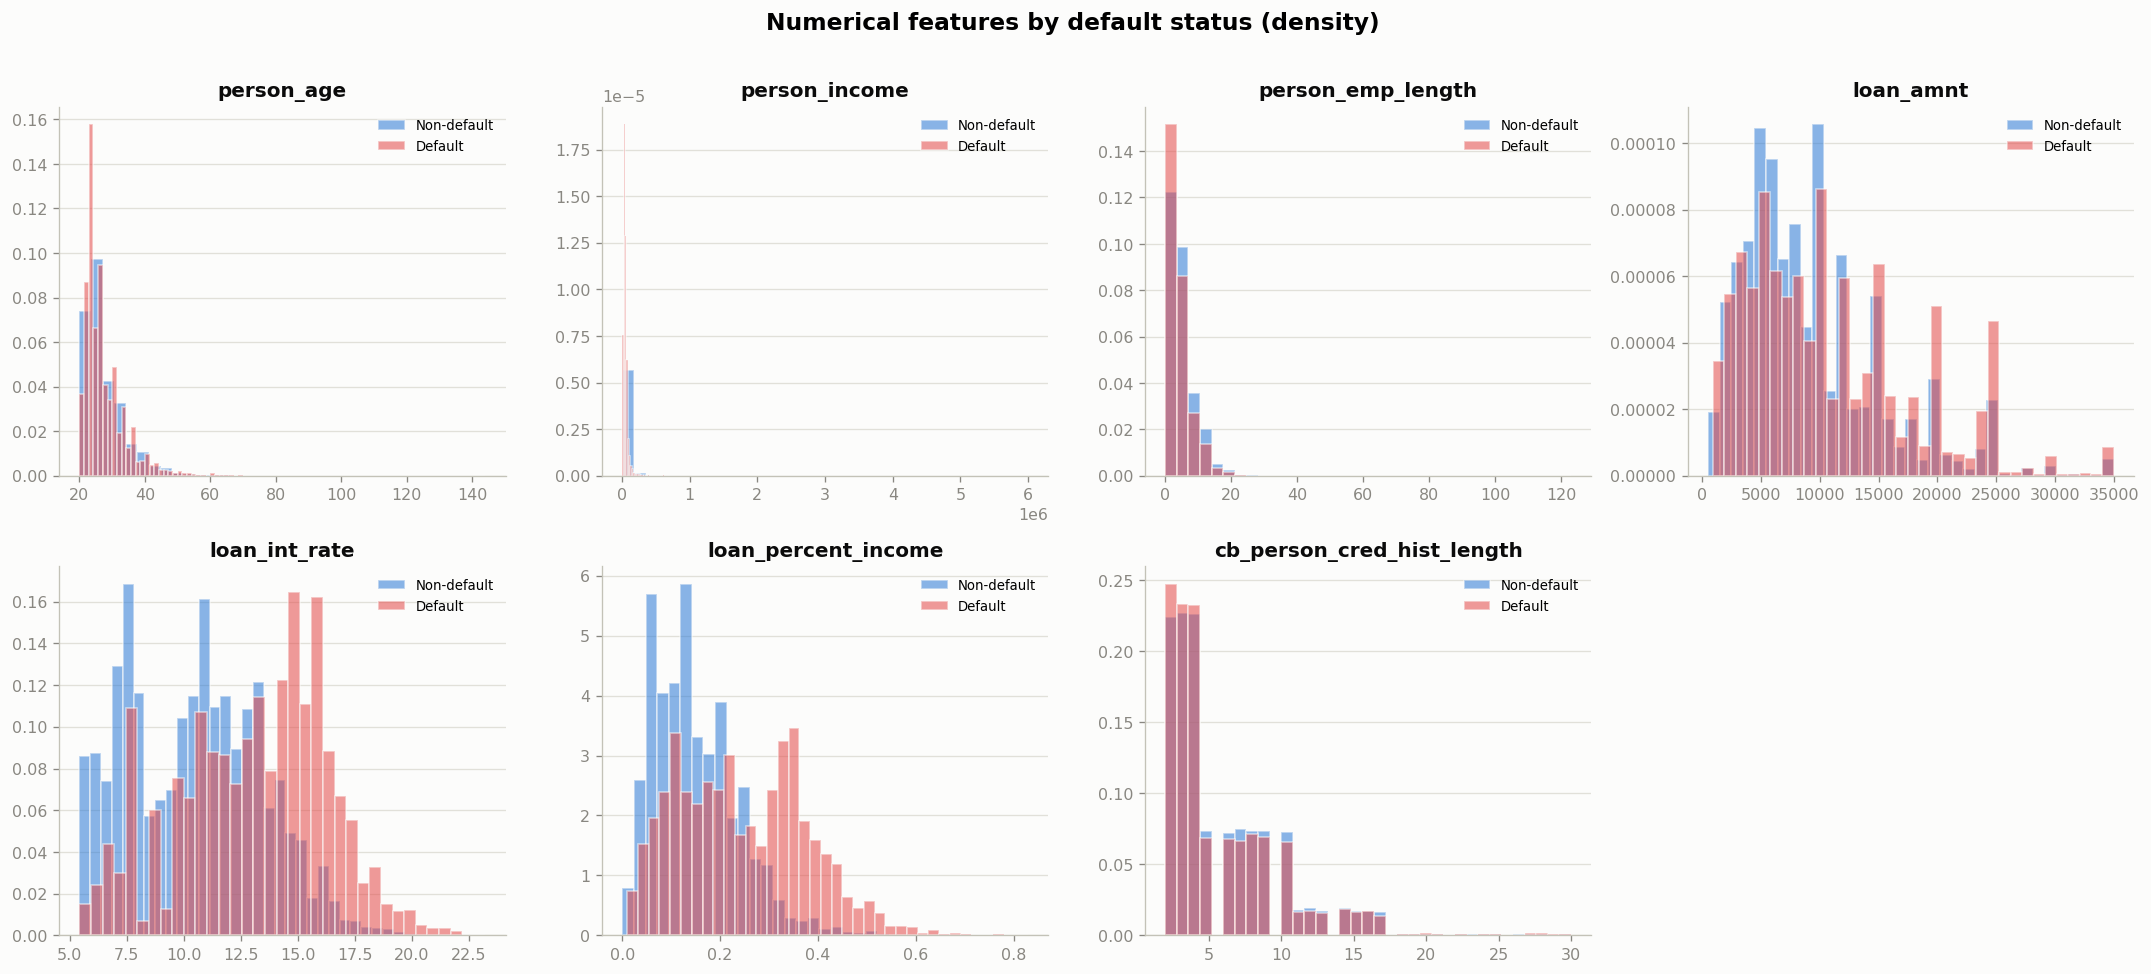

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    for status in [0, 1]:
        data = df.loc[df['loan_status'] == status, col].dropna()
        ax.hist(data, bins=35, alpha=0.55,
                color=TARGET_COLORS[status], label=TARGET_LABELS[status],
                density=True, edgecolor='#fcfcfb')
    ax.set_title(col)
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Numerical features by default status (density)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

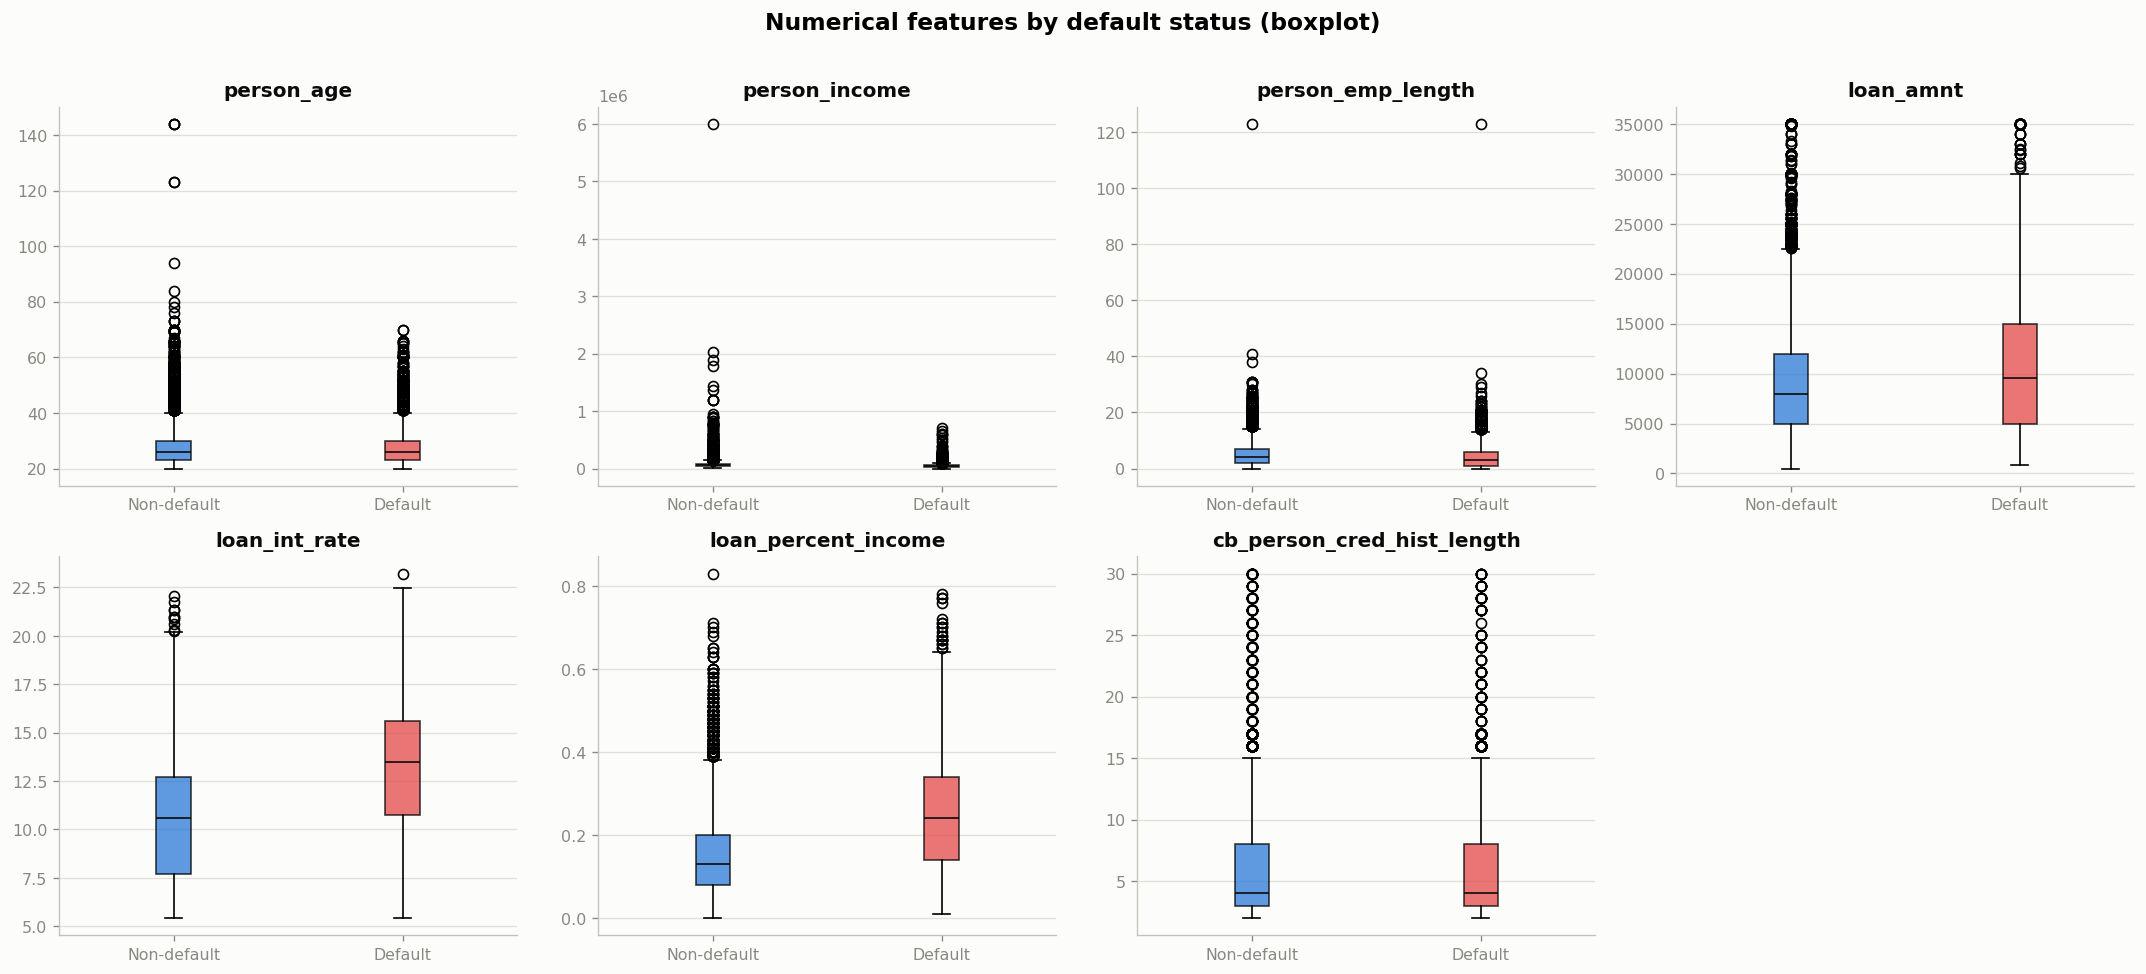

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    data_to_plot = [df.loc[df['loan_status'] == s, col].dropna().values
                    for s in [0, 1]]
    bp = ax.boxplot(data_to_plot, patch_artist=True,
                    tick_labels=[TARGET_LABELS[0], TARGET_LABELS[1]])
    for patch, color in zip(bp['boxes'], [TARGET_COLORS[0], TARGET_COLORS[1]]):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    for median in bp['medians']:
        median.set_color('#0b0b0b')
    ax.set_title(col)

axes[-1].set_visible(False)
plt.suptitle('Numerical features by default status (boxplot)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [11]:
# Mean comparison table
summary = df.groupby('loan_status')[num_cols].mean().T.round(2)
summary.columns = ['Non-default', 'Default']
summary['Difference (%)'] = ((summary['Default'] - summary['Non-default'])
                              / summary['Non-default'] * 100).round(1)
print(summary.to_string())

                            Non-default   Default  Difference (%)
person_age                        27.81     27.47            -1.2
person_income                  70804.36  49125.65           -30.6
person_emp_length                  4.97      4.14           -16.7
loan_amnt                       9237.46  10850.50            17.5
loan_int_rate                     10.44     13.06            25.1
loan_percent_income                0.15      0.25            66.7
cb_person_cred_hist_length         5.84      5.69            -2.6


Key observations:

- **`loan_percent_income`** shows the clearest separation: defaulters carry a much higher debt-to-income ratio on average.
- **`loan_int_rate`** is also strongly discriminating, consistent with its near-perfect correlation with `loan_grade`.
- **`person_income`** is lower for defaulters, as expected.
- **`person_age`** and **`cb_person_cred_hist_length`** show little separation, though both are correlated with each other (older borrowers have longer histories).

## 7. Correlation analysis

We look at pairwise correlations between numerical features to anticipate multicollinearity issues in the models. Two pairs stand out: `loan_grade` / `loan_int_rate` (0.93) and `person_age` / `cb_person_cred_hist_length` (0.86). These will affect how linear models assign coefficients.

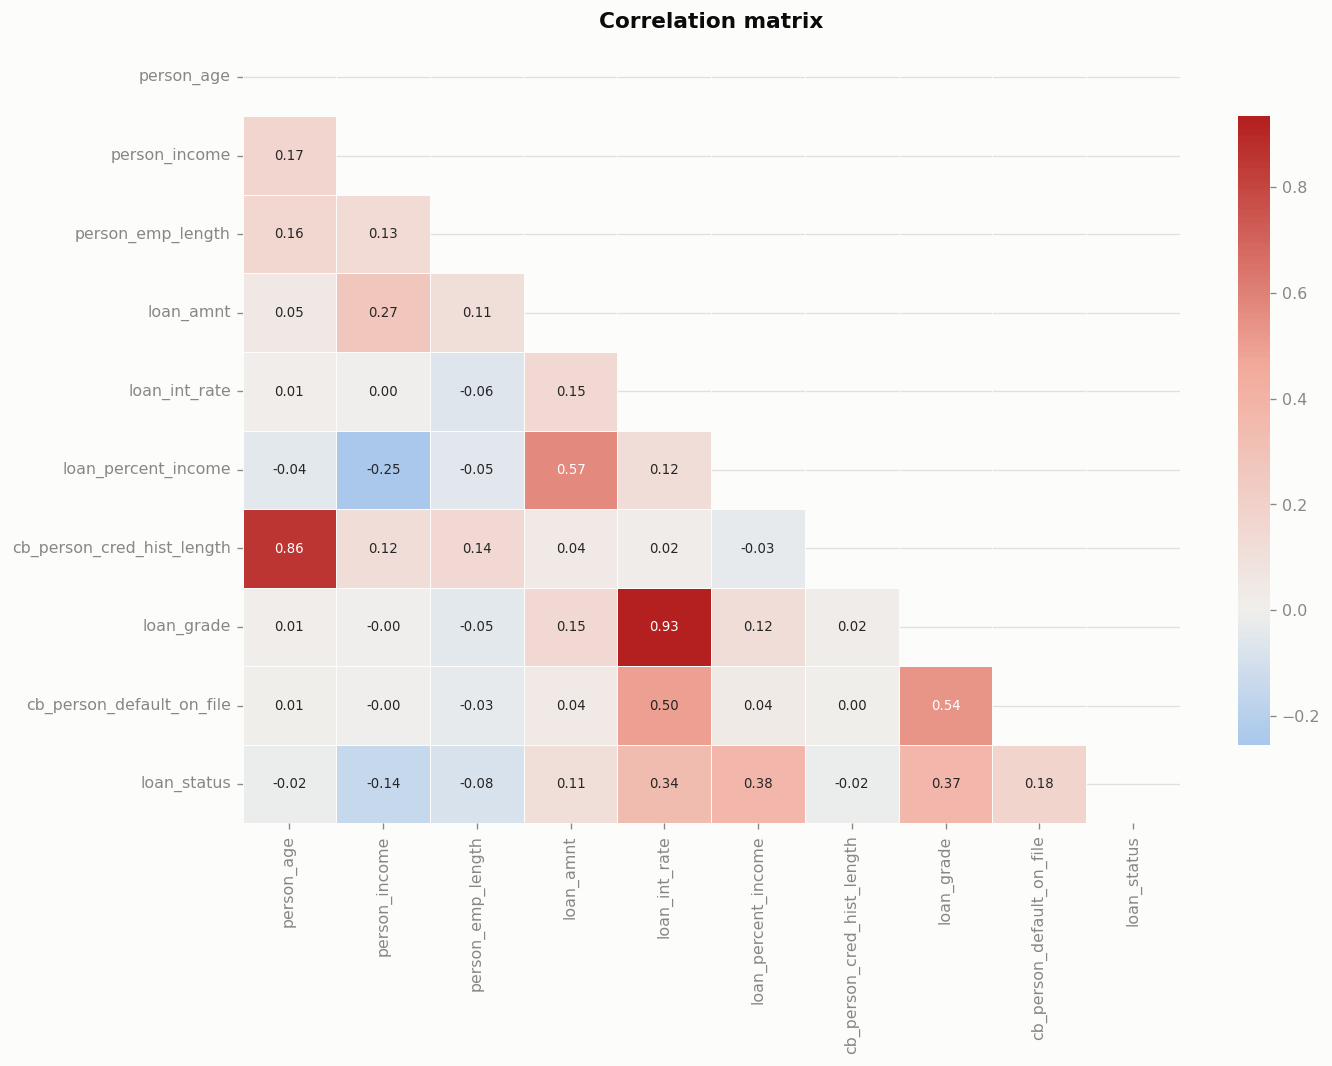

In [12]:
# Ordinal encode loan_grade for correlation computation
df_corr = df.copy()
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df_corr['loan_grade'] = df_corr['loan_grade'].map(grade_map)
df_corr['cb_person_default_on_file'] = df_corr['cb_person_default_on_file'].map({'Y': 1, 'N': 0})

corr_cols = num_cols + ['loan_grade', 'cb_person_default_on_file', 'loan_status']
corr_matrix = df_corr[corr_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f', cmap=DIVERGING_BLUE_RED, center=0,
    linewidths=.4, linecolor='#fcfcfb', annot_kws={'size': 8},
    cbar_kws={'shrink': .8}
)
plt.title('Correlation matrix', fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
# Top correlations with the target
target_corr = corr_matrix['loan_status'].drop('loan_status').sort_values(key=abs, ascending=False)
print('Correlation with loan_status (sorted by absolute value):')
print(target_corr.round(3).to_string())

Correlation with loan_status (sorted by absolute value):
loan_percent_income           0.379
loan_grade                    0.373
loan_int_rate                 0.335
cb_person_default_on_file     0.179
person_income                -0.144
loan_amnt                     0.105
person_emp_length            -0.082
person_age                   -0.022
cb_person_cred_hist_length   -0.016


## 8. Statistical significance testing

The bivariate plots suggest visual separation between defaulters and non-defaulters, but eyeballing a histogram isn't a substitute for a formal test. Numerical features are compared with the Mann-Whitney U test (non-parametric, appropriate given the skewed distributions seen earlier, unlike a t-test which assumes normality). Categorical features are compared with a chi-square test of independence against the target.

In [14]:
from scipy import stats

rows = []
for col in num_cols:
    group0 = df.loc[df['loan_status'] == 0, col].dropna()
    group1 = df.loc[df['loan_status'] == 1, col].dropna()
    u_stat, p_value = stats.mannwhitneyu(group0, group1, alternative='two-sided')
    # rank-biserial correlation as effect size: 0 = no separation, 1 = perfect separation
    effect_size = abs(1 - (2 * u_stat) / (len(group0) * len(group1)))
    rows.append({'Feature': col, 'p-value': p_value, 'Effect size (rank-biserial)': effect_size})

df_numeric_tests = pd.DataFrame(rows).sort_values('Effect size (rank-biserial)', ascending=False)
df_numeric_tests['p-value'] = df_numeric_tests['p-value'].apply(lambda p: '<0.001' if p < 0.001 else f'{p:.3f}')
print('Mann-Whitney U test: numerical features vs loan_status')
print(df_numeric_tests.round(3).to_string(index=False))

Mann-Whitney U test: numerical features vs loan_status
                   Feature p-value  Effect size (rank-biserial)
             loan_int_rate  <0.001                        0.447
       loan_percent_income  <0.001                        0.442
             person_income  <0.001                        0.380
         person_emp_length  <0.001                        0.136
                 loan_amnt  <0.001                        0.117
                person_age  <0.001                        0.046
cb_person_cred_hist_length  <0.001                        0.033


In [15]:
cat_cols_raw = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

rows = []
for col in cat_cols_raw:
    contingency = pd.crosstab(df[col], df['loan_status'])
    chi2, p_value, dof, _ = stats.chi2_contingency(contingency)
    n = contingency.sum().sum()
    # Cramer's V as effect size: 0 = no association, 1 = perfect association
    cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
    rows.append({'Feature': col, 'p-value': p_value, "Effect size (Cramer's V)": cramers_v})

df_cat_tests = pd.DataFrame(rows).sort_values("Effect size (Cramer's V)", ascending=False)
df_cat_tests['p-value'] = df_cat_tests['p-value'].apply(lambda p: '<0.001' if p < 0.001 else f'{p:.3f}')
print("Chi-square test: categorical features vs loan_status")
print(df_cat_tests.round(3).to_string(index=False))

Chi-square test: categorical features vs loan_status
                  Feature p-value  Effect size (Cramer's V)
               loan_grade  <0.001                     0.415
    person_home_ownership  <0.001                     0.242
cb_person_default_on_file  <0.001                     0.179
              loan_intent  <0.001                     0.126


## 9. Multicollinearity diagnostics (VIF)

The correlation heatmap flagged `loan_grade`/`loan_int_rate` (0.93) and `person_age`/`cb_person_cred_hist_length` (0.86) as highly correlated. The Variance Inflation Factor (VIF) formalizes this: a VIF above 5 signals that a feature's variance is inflated by collinearity with the other predictors, which destabilizes coefficient estimates in linear models. This is directly relevant since the champion model is a regularized logistic regression, and it explains why L1 regularization (which can zero out redundant coefficients) was a sensible choice there.

In [16]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_features = num_cols + ['loan_grade', 'cb_person_default_on_file']
X_vif = df_corr[vif_features].dropna()
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_data = vif_data[vif_data['Feature'] != 'const'].sort_values('VIF', ascending=False)
print('Variance Inflation Factor (dropping rows with missing values):')
print(vif_data.round(2).to_string(index=False))

Variance Inflation Factor (dropping rows with missing values):
                   Feature  VIF
                loan_grade 8.20
             loan_int_rate 7.79
                person_age 3.94
cb_person_cred_hist_length 3.86
                 loan_amnt 2.12
       loan_percent_income 2.07
             person_income 1.51
 cb_person_default_on_file 1.41
         person_emp_length 1.06


## 10. Predictive power ranking: Weight of Evidence and Information Value

Weight of Evidence (WoE) and Information Value (IV) are standard credit-scoring diagnostics, more domain-appropriate here than a generic feature-importance measure. For each bin of a feature, WoE measures how much the odds of default differ from the population average; IV aggregates this across all bins into a single score ranking the feature's overall predictive power. Numerical features are binned into deciles; categorical features use their existing categories.

Rule of thumb: IV < 0.02 not predictive, 0.02-0.1 weak, 0.1-0.3 medium, 0.3-0.5 strong, > 0.5 suspiciously strong (worth checking for leakage).

In [17]:
def compute_iv(data, feature, target, bins=10, is_numeric=True):
    d = data[[feature, target]].dropna().copy()
    d['bin'] = pd.qcut(d[feature], q=bins, duplicates='drop') if is_numeric else d[feature]

    grouped = d.groupby('bin', observed=True)[target].agg(['count', 'sum'])
    grouped.columns = ['total', 'events']
    grouped['non_events'] = grouped['total'] - grouped['events']

    event_rate = grouped['events'] / grouped['events'].sum()
    non_event_rate = grouped['non_events'] / grouped['non_events'].sum()

    eps = 1e-6  # avoids log(0) for bins with zero events or non-events
    woe = np.log((non_event_rate + eps) / (event_rate + eps))
    iv = ((non_event_rate - event_rate) * woe).sum()
    return iv


def iv_strength(iv):
    if iv < 0.02:
        return 'Not predictive'
    if iv < 0.1:
        return 'Weak'
    if iv < 0.3:
        return 'Medium'
    if iv < 0.5:
        return 'Strong'
    return 'Suspiciously strong (check leakage)'


iv_rows = []
for feat in num_cols:
    iv_rows.append({'Feature': feat, 'IV': compute_iv(df, feat, 'loan_status', bins=10, is_numeric=True)})
for feat in cat_cols_raw:
    iv_rows.append({'Feature': feat, 'IV': compute_iv(df, feat, 'loan_status', is_numeric=False)})

df_iv = pd.DataFrame(iv_rows).sort_values('IV', ascending=False)
df_iv['Strength'] = df_iv['IV'].apply(iv_strength)
print(df_iv.round(3).to_string(index=False))

                   Feature    IV                            Strength
                loan_grade 0.881 Suspiciously strong (check leakage)
       loan_percent_income 0.871 Suspiciously strong (check leakage)
             loan_int_rate 0.737 Suspiciously strong (check leakage)
             person_income 0.470                              Strong
     person_home_ownership 0.377                              Strong
 cb_person_default_on_file 0.164                              Medium
               loan_intent 0.096                                Weak
                 loan_amnt 0.086                                Weak
         person_emp_length 0.061                                Weak
                person_age 0.010                      Not predictive
cb_person_cred_hist_length 0.004                      Not predictive


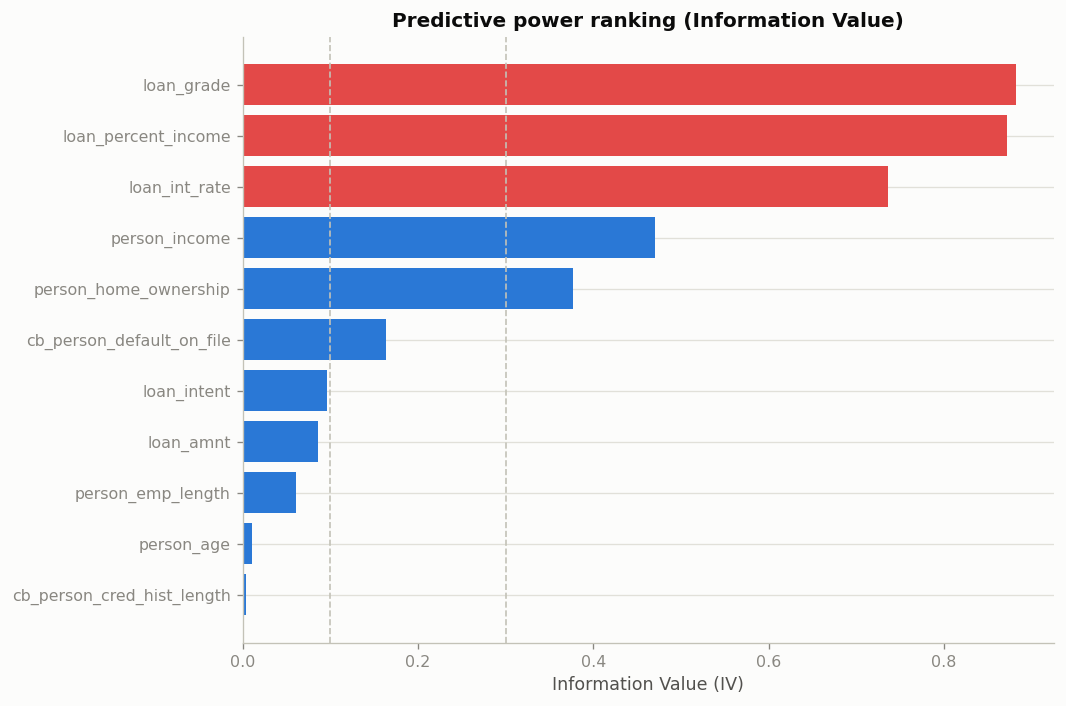

In [18]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = [RED if s.startswith('Suspiciously') else BLUE for s in df_iv['Strength']]
ax.barh(df_iv['Feature'][::-1], df_iv['IV'][::-1], color=colors[::-1])
ax.set_xlabel('Information Value (IV)')
ax.set_title('Predictive power ranking (Information Value)')
ax.axvline(0.1, color=AXIS_LINE, linestyle='--', linewidth=1)
ax.axvline(0.3, color=AXIS_LINE, linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('information_value.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

The main takeaways from this EDA:

- **`loan_grade`**, **`loan_percent_income`**, and **`loan_int_rate`** are the strongest predictors of default (IV > 0.5), confirmed by both the Mann-Whitney/chi-square tests (p < 0.001) and by Information Value. IV this high is normally a leakage red flag, but here it makes domain sense: `loan_grade` and `loan_int_rate` are underwriting fields set *at* origination specifically to price risk, so they are legitimately available before a default outcome is known, not proxies for it.
- **`loan_grade`** and **`loan_int_rate`** also have the two highest VIFs (8.20 and 7.79), confirming the near-perfect correlation (0.93) seen in the heatmap. This will create instability in linear model coefficients and is why L1 regularization (which can zero out one of a redundant pair) is a sensible choice for the champion model.
- **`person_home_ownership`** and `person_income` are strong secondary predictors (IV 0.38 and 0.47): renters default at roughly 3x the rate of owners, and defaulters earn ~30% less on average (both statistically significant, Cramer's V = 0.24 and rank-biserial = 0.38 respectively).
- **`person_age`** and **`cb_person_cred_hist_length`** are the weakest features (IV < 0.02, "not predictive" by the standard IV rule of thumb) despite being statistically significant at this sample size, a reminder that with n=32,581, even a negligible effect size can produce p < 0.001.
- Missing values in `loan_int_rate` (9.6%) and `person_emp_length` (2.7%) should be treated with indicator variables to preserve any predictive signal carried by the absence of data.
- A handful of outliers in `person_age` and `person_emp_length` are clearly erroneous and should be removed before modeling.